# Heterogeneite entre les tumoroids

Ce qu'on fait dans ce notebook :
1. charger les donnees et reconstruire les sous-ensembles par tumoroid
2. regarder combien de genes sont exprimes dans tous les tumoroids
3. faire une PCA et un clustering hierarchique sur les profils moyens
4. calculer d'autres mesures d'heterogeneite (CV, heatmap de correlation)

## 1. Imports et chargement des donnees

On charge les librairies nécessaire, plus sklearn pour la PCA et scipy pour le clustering. Je recharge aussi le JSON des polygones pour reconstruire les adata par tumoroid.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from shapely.geometry import Polygon, Point
from sklearn.decomposition import PCA

sys.path.append('/Users/yasmine/Documents/stage_yasmine/stage/the_during/phase1/scripts')
from CreateSquidpyBMKObject import create_s1000_object

matrix_path = '/Users/yasmine/Documents/stage_yasmine/stage/the_during/phase1/scripts/level_1/level_1'
png_path    = '/Users/yasmine/Documents/stage_yasmine/stage/the_during/phase1/scripts/level_1/pics/he_roi_small.png'
JSON_PATH   = 'polygones_tumoroids.json'

adata = create_s1000_object(
    matrix_path, png_path,
    spot_radius=1, min_cells=5, min_features=40, resolution='spot'
)

coords    = adata.obsm['spatial']
gene_names = adata.var_names

print(f'{adata.n_obs} spots, {adata.n_vars} genes')

167598 spots, 26283 genes


On recharge les polygones depuis le JSON et on reconstruit un adata par tumoroid, comme dans polygon_annotation. On teste si chaque spot est dans le polygone avec shapely.

In [2]:
with open(JSON_PATH) as f:
    polygons_data = json.load(f)

polygons = {name: Polygon(pts) for name, pts in polygons_data.items()}

adata_tumoroids = {}
for name in sorted(polygons):
    mask = np.array([polygons[name].contains(Point(x, y)) for x, y in coords])
    adata_tumoroids[name] = adata[mask].copy()
    print(f'{name}: {adata_tumoroids[name].n_obs} spots')

tumoroid_names = sorted(adata_tumoroids.keys())

T1: 5765 spots
T2: 12888 spots
T3: 10524 spots
T4: 9159 spots
T5: 7333 spots
T6: 17896 spots
T7: 5499 spots
T8: 9284 spots
T9: 10496 spots


## 2. Pourcentage de genes exprimes dans tous les tumoroids

Pour chaque gene, on regarde dans combien de tumoroids il est exprime (au moins 1 spot > 0). Ca permet de voir ce qui est partage entre tous les tumoroids vs ce qui est specifique a certains.

In [3]:
n_tumoroids = len(tumoroid_names)

# pour chaque gene, compter dans combien de tumoroids il est exprime
presence = np.zeros(len(gene_names), dtype=int)

for name in tumoroid_names:
    adata_t = adata_tumoroids[name]
    # un gene est exprime si au moins 1 spot a une valeur > 0
    expressed = np.asarray((adata_t.X > 0).sum(axis=0)).flatten() > 0
    # les genes de adata_t ne sont pas forcement dans le meme ordre que adata
    # donc on retrouve les indices dans gene_names
    idx_in_full = [list(gene_names).index(g) for g in adata_t.var_names]
    for i, idx in enumerate(idx_in_full):
        if expressed[i]:
            presence[idx] += 1

# afficher le bilan
print(f'Nombre total de genes : {len(gene_names)}')
print()
for k in range(n_tumoroids + 1):
    n = (presence == k).sum()
    print(f'  exprimes dans {k}/{n_tumoroids} tumoroids : {n} genes ({100*n/len(gene_names):.1f}%)')

n_tous = (presence == n_tumoroids).sum()
print(f'\n {n_tous} genes ({100*n_tous/len(gene_names):.1f}%) sont exprimes dans les 9 tumoroids')

Nombre total de genes : 26283

  exprimes dans 0/9 tumoroids : 79 genes (0.3%)
  exprimes dans 1/9 tumoroids : 535 genes (2.0%)
  exprimes dans 2/9 tumoroids : 1433 genes (5.5%)
  exprimes dans 3/9 tumoroids : 1983 genes (7.5%)
  exprimes dans 4/9 tumoroids : 1808 genes (6.9%)
  exprimes dans 5/9 tumoroids : 1618 genes (6.2%)
  exprimes dans 6/9 tumoroids : 1622 genes (6.2%)
  exprimes dans 7/9 tumoroids : 1645 genes (6.3%)
  exprimes dans 8/9 tumoroids : 2146 genes (8.2%)
  exprimes dans 9/9 tumoroids : 13414 genes (51.0%)

 13414 genes (51.0%) sont exprimes dans les 9 tumoroids


**Mon interpretation :**  
51% des genes (13 414 sur 26 283) sont exprimes dans tous les tumoroids. Il exise  un transcriptome commun stable entre tous les tumoroides annotes.

On trace un histogramme pour visualiser la distribution.

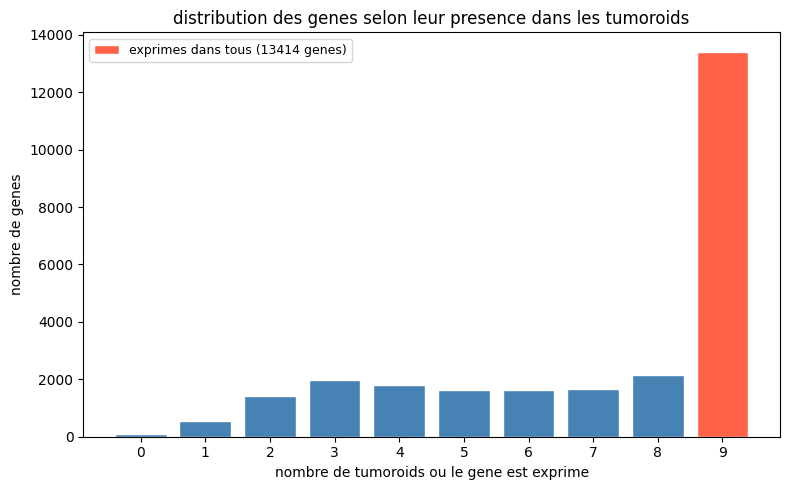

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = [(presence == k).sum() for k in range(n_tumoroids + 1)]
ax.bar(range(n_tumoroids + 1), counts, color='steelblue', edgecolor='white')

ax.set_xlabel('nombre de tumoroids ou le gene est exprime')
ax.set_ylabel('nombre de genes')
ax.set_title('distribution des genes selon leur presence dans les tumoroids')
ax.set_xticks(range(n_tumoroids + 1))

# annoter la barre des 9 tumoroids
ax.bar(n_tumoroids, counts[n_tumoroids], color='tomato', edgecolor='white', label=f'exprimes dans tous ({counts[n_tumoroids]} genes)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('presence_genes_tumoroids.png', dpi=150)
plt.show()

## 3. PCA et clustering hierarchique sur les profils moyens

On resumes chaque tumoroid par son profil d'expression moyen : pour chaque gene, on prend la moyenne sur tous les spots du tumoroid. Ca donne une matrice 9 x G (9 tumoroids, G genes). On garde seulement les genes exprimes dans au moins 2 tumoroids pour eviter que les genes tres rares bruitent les resultats.

In [5]:
# garder seulement les genes exprimes dans au moins 2 tumoroids
gene_filter = presence >= 2
gene_names_filtered = gene_names[gene_filter]
print(f'genes gardes (presence >= 2 tumoroids) : {gene_filter.sum()}')

# construire la matrice moyenne 9 x G
mean_matrix = np.zeros((len(tumoroid_names), gene_filter.sum()))

for i, name in enumerate(tumoroid_names):
    adata_t = adata_tumoroids[name]
    # retrouver les genes filtres qui sont aussi dans ce tumoroid
    genes_communs = [g for g in gene_names_filtered if g in adata_t.var_names]
    idx_dans_t    = [list(adata_t.var_names).index(g) for g in genes_communs]
    idx_dans_filt = [list(gene_names_filtered).index(g) for g in genes_communs]
    
    moyennes = np.asarray(adata_t.X[:, idx_dans_t].mean(axis=0)).flatten()
    mean_matrix[i, idx_dans_filt] = moyennes

print(f'matrice moyenne construite : {mean_matrix.shape}')

genes gardes (presence >= 2 tumoroids) : 25669
matrice moyenne construite : (9, 25669)


On fais une PCA sur cette matrice.

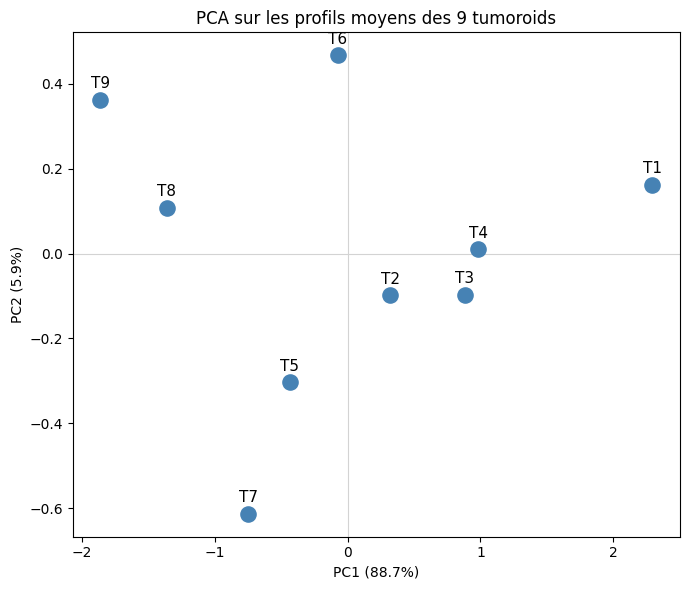

variance expliquee par composante :
  PC1 : 88.7%
  PC2 : 5.9%
  PC3 : 3.6%
  PC4 : 0.8%
  PC5 : 0.6%
  PC6 : 0.2%
  PC7 : 0.1%
  PC8 : 0.1%
  PC9 : 0.0%


In [6]:
pca = PCA(n_components=min(9, mean_matrix.shape[0]))
coords_pca = pca.fit_transform(mean_matrix)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(coords_pca[:, 0], coords_pca[:, 1], s=120, color='steelblue', zorder=3)

for i, name in enumerate(tumoroid_names):
    ax.annotate(name, (coords_pca[i, 0], coords_pca[i, 1]),
                fontsize=11, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA sur les profils moyens des 9 tumoroids')
ax.axhline(0, color='lightgray', linewidth=0.8)
ax.axvline(0, color='lightgray', linewidth=0.8)

plt.tight_layout()
plt.savefig('pca_tumoroids.png', dpi=150)
plt.show()

# variance expliquee par composante
print('variance expliquee par composante :')
for k, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{k+1} : {v*100:.1f}%')

**Mon interpretation :** PC1 explique 88.7% de la variance, presque toute la variabilité entre tumoroids se résume à un seul axe.   
Je pense que c'est leur position dans l'espace, plus les tumoroides sont proches dans l'espace, plus ils le sont sur  la PCA, et  vice-versa.  
Je pense que le deuxieme axe est la taille des tomoroides, T6 (17 896 spots) et T7 (5499 spots) sont aux extremes en taille.  
(a la fin du  reste des analyses  je trouve que PC1 correspons plutot au  profil d'expression des tumoroides)

Le clustering hierarchique regroupe les tumoroids par similarite de profil. J'utilise la distance de correlation (1 - correlation de Pearson) et la methode de Ward pour construire le dendrogramme.

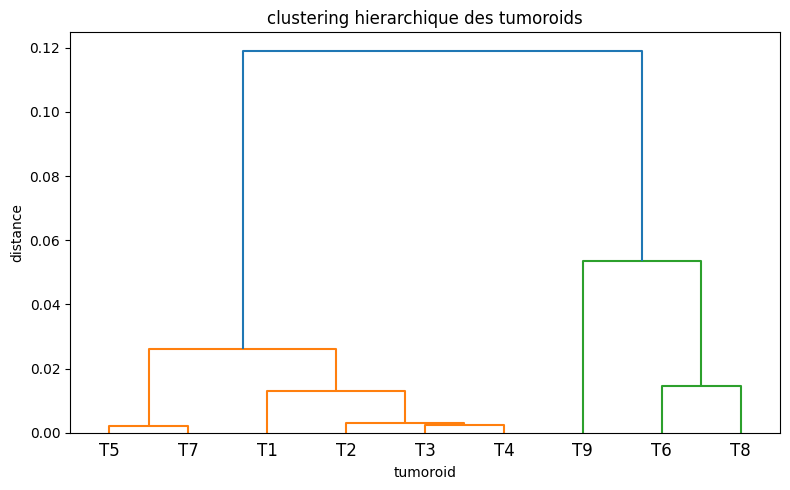

In [7]:
# distance de correlation entre profils moyens
dist = pdist(mean_matrix, metric='correlation')
linkage = sch.linkage(dist, method='ward')

fig, ax = plt.subplots(figsize=(8, 5))
sch.dendrogram(linkage, labels=tumoroid_names, ax=ax, leaf_font_size=12)

ax.set_title('clustering hierarchique des tumoroids')
ax.set_ylabel('distance')
ax.set_xlabel('tumoroid')

plt.tight_layout()
plt.savefig('dendrogramme_tumoroids.png', dpi=150)
plt.show()

**Mon interpretation :**   
Le T4 T3 T2 ont des tailles proches , mais le T9 et le T3 ont les tailles les plus proche, pourtant ils se regroupent pas ici. Les groupes ne sont pas vraiment proche  dans l'espace , à part pour T2 T3 et T4.  
Ni la  taille ni la position  spatial explique bien les groupes.  


In [8]:
groupe_vert   = ['T6', 'T8', 'T9']
groupe_orange = ['T1', 'T2', 'T3', 'T4', 'T5', 'T7']

idx_vert   = [tumoroid_names.index(t) for t in groupe_vert]
idx_orange = [tumoroid_names.index(t) for t in groupe_orange]

mean_vert   = mean_matrix[idx_vert, :].mean(axis=0)
mean_orange = mean_matrix[idx_orange, :].mean(axis=0)

# on garde seulement les genes suffisamment exprimes dans au moins un groupe
filtre = (mean_vert > 0.01) | (mean_orange > 0.01)
print(f'genes avec expression > 0.01 dans au moins un groupe : {filtre.sum()}')

mean_vert_f   = mean_vert[filtre]
mean_orange_f = mean_orange[filtre]
noms_filtres  = gene_names_filtered[filtre]

epsilon = 1e-6  #Pour eviter la division  sur 0
fold_change = (mean_vert_f + epsilon) / (mean_orange_f + epsilon)

# genes surexprimes dans T6/T8/T9
top_vert = np.argsort(fold_change)[::-1][:20]
print("\ngenes plus exprimes dans T6/T8/T9 :")
for idx in top_vert:
    print(f"  {noms_filtres[idx]:15}  FC = {fold_change[idx]:.2f}   moy_vert = {mean_vert_f[idx]:.4f}   moy_orange = {mean_orange_f[idx]:.4f}")

print()

# genes surexprimes dans T1/T2/T3/T4/T5/T7
top_orange = np.argsort(fold_change)[:20]
print("genes plus exprimes dans T1/T2/T3/T4/T5/T7 :")
for idx in top_orange:
    print(f"  {noms_filtres[idx]:15}  FC = {fold_change[idx]:.2f}   moy_vert = {mean_vert_f[idx]:.4f}   moy_orange = {mean_orange_f[idx]:.4f}")



genes avec expression > 0.01 dans au moins un groupe : 1023

genes plus exprimes dans T6/T8/T9 :
  MT-TV            FC = 4.84   moy_vert = 1.0572   moy_orange = 0.2183
  MT-TD            FC = 2.65   moy_vert = 0.0964   moy_orange = 0.0364
  MT-TL1           FC = 2.44   moy_vert = 0.3845   moy_orange = 0.1575
  AC132217.2       FC = 1.86   moy_vert = 0.0192   moy_orange = 0.0103
  BNIP3            FC = 1.82   moy_vert = 0.0125   moy_orange = 0.0069
  MT-TK            FC = 1.79   moy_vert = 0.0123   moy_orange = 0.0069
  DLK1             FC = 1.78   moy_vert = 0.0535   moy_orange = 0.0300
  H19              FC = 1.78   moy_vert = 0.0433   moy_orange = 0.0244
  RGS4             FC = 1.77   moy_vert = 0.0109   moy_orange = 0.0062
  IGF2             FC = 1.76   moy_vert = 0.0195   moy_orange = 0.0111
  MT-TS2           FC = 1.68   moy_vert = 0.1339   moy_orange = 0.0799
  AC005726.1       FC = 1.64   moy_vert = 0.0108   moy_orange = 0.0066
  MT-TF            FC = 1.64   moy_vert = 0.1390   

**La recherche avec `g:profiler` donne ça :**    
_Pour le groupe T6/T8/T9 :_   
Les termes enrichis sont liés à la mitochondrie, ce qui suggere que ces tumoroids ont une activité mitochondriale plus forte que les autres. C'est cohérent avec ce qu'on observait dans le fold change avec les gènes MT-T.

_Pour le groupe T1/T2/T3/T4/T5/T7 :_  
Les termes HP enrichis indiquent que les gènes surexprimés dans ce groupe sont connus pour jouer un rôle dans le développement neuronal (quand ils sont mutés chez l'humain, ils causent des phenotypes neurologiques). Cela suggere que ce groupe de tumoroids a un profil d'expression plus neuronal et différencié.


## 4. Autres mesures d'heterogeneite

Deux mesures complementaires : le coefficient de variation (CV) par gene pour voir quels genes varient le plus entre tumoroids, et une heatmap de correlation pour avoir une vue d'ensemble des similarites deux a deux.

### 4a. Coefficient de variation par gene

Le CV = ecart-type / moyenne, calcule sur les 9 valeurs moyennes d'un gene (une par tumoroid). Un CV eleve signifie que ce gene est tres variable entre tumoroids.

genes avec moyenne > 0.01 : 953 (3.7%)
top 20 genes les plus variables entre tumoroids (CV) :

   1. MT-TV            CV = 0.82   mean = 0.4979
   2. MT-TD            CV = 0.58   mean = 0.0564
   3. ERBB4            CV = 0.54   mean = 0.0106
   4. MT-TL1           CV = 0.53   mean = 0.2331
   5. SGCZ             CV = 0.51   mean = 0.0152
   6. RIMS2            CV = 0.45   mean = 0.0100
   7. AC132217.2       CV = 0.43   mean = 0.0133
   8. H19              CV = 0.42   mean = 0.0307
   9. AC109466.1       CV = 0.42   mean = 0.0116
  10. FAM49A           CV = 0.42   mean = 0.0325
  11. SEMA3A           CV = 0.40   mean = 0.0117
  12. IGF2             CV = 0.40   mean = 0.0139
  13. LINGO2           CV = 0.39   mean = 0.0126
  14. MT-TS2           CV = 0.39   mean = 0.0979
  15. MT-TW            CV = 0.39   mean = 0.0145
  16. RNA5-8SN1        CV = 0.39   mean = 0.0645
  17. FP671120.4       CV = 0.38   mean = 0.0703
  18. RNA5-8SN2        CV = 0.38   mean = 0.0617
  19. DACH1            

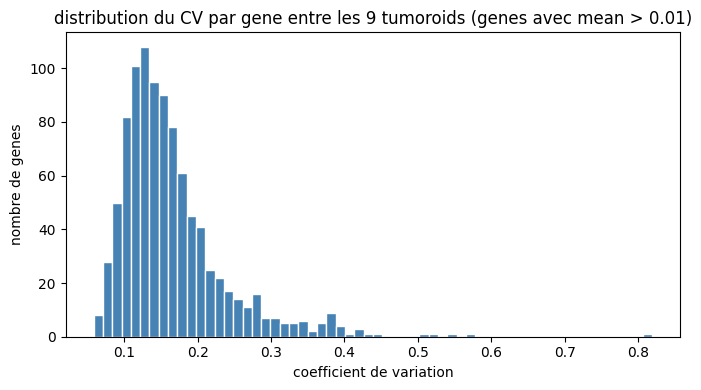

In [9]:
# moyenne et ecart-type de chaque gene sur les 9 tumoroids
mean_per_gene = mean_matrix.mean(axis=0)
std_per_gene  = mean_matrix.std(axis=0)

# on calcule le CV uniquement pour les genes avec une moyenne > 0.01
# les autres sont mis a 0 pour les exclure du classement
filtre_mean = mean_per_gene > 0.01
cv = np.where(filtre_mean, std_per_gene / mean_per_gene, 0)

nb_genes_filtres = filtre_mean.sum()
print(f'genes avec moyenne > 0.01 : {nb_genes_filtres} ({100*nb_genes_filtres/len(mean_per_gene):.1f}%)')

# top 20 genes les plus heterogenes
top_idx = np.argsort(cv)[::-1][:20]
print('top 20 genes les plus variables entre tumoroids (CV) :')
print()
for rank, idx in enumerate(top_idx, 1):
    print(f'  {rank:2}. {gene_names_filtered[idx]:15}  CV = {cv[idx]:.2f}   mean = {mean_per_gene[idx]:.4f}')

# distribution globale du CV
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cv[cv > 0], bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('coefficient de variation')
ax.set_ylabel('nombre de genes')
ax.set_title('distribution du CV par gene entre les 9 tumoroids (genes avec mean > 0.01)')
plt.tight_layout()
plt.savefig('cv_genes_tumoroids.png', dpi=150)
plt.show()

**Apres recherche  des fonction des genes sur genecards.com :**  
Les genes les plus variables entre tumoroids se regroupent en trois categories.  

La premiere ce sont les genes mitochondriaux (MT-TV, MT-TD, MT-TL1, MT-TS2, MT-TW). Ils sont tous impliques dans la fabrication des proteines a l'interieur de la mitochondrie. Le fait qu'ils varient beaucoup entre tumoroids suggere que certains tumoroids ont une activite mitochondriale plus forte que d'autres.

La deuxieme categorie regroupe H19 et IGF2, deux genes situes au meme endroit sur le chromosome 11. H19 produit un ARN non-codant qui freine la croissance tumorale, et IGF2 est un facteur de croissance. Ces deux genes sont regules ensemble et leur variabilite entre tumoroids suggere que certains tumoroids ont un potentiel de croissance plus actif que d'autres.

La troisieme categorie regroupe des genes lies a la differenciation neuronale : ERBB4 est un recepteur implique dans la signalisation entre cellules nerveuses, RIMS2 joue un role dans la liberation des neurotransmetteurs au niveau des synapses, SEMA3A guide la croissance des axones, LINGO2 participe a la formation des synapses, et DACH1 est un facteur de transcription dont la perte est associee aux cancers. La variabilite de ces genes entre tumoroids indique qu'ils ne sont pas tous au meme stade de differenciation neuronale.

En resume, les tumoroids se distinguent principalement sur trois aspects : leur niveau d'activite mitochondriale, leur regulation de la croissance via le locus H19/IGF2, et leur degre de differenciation neuronale.

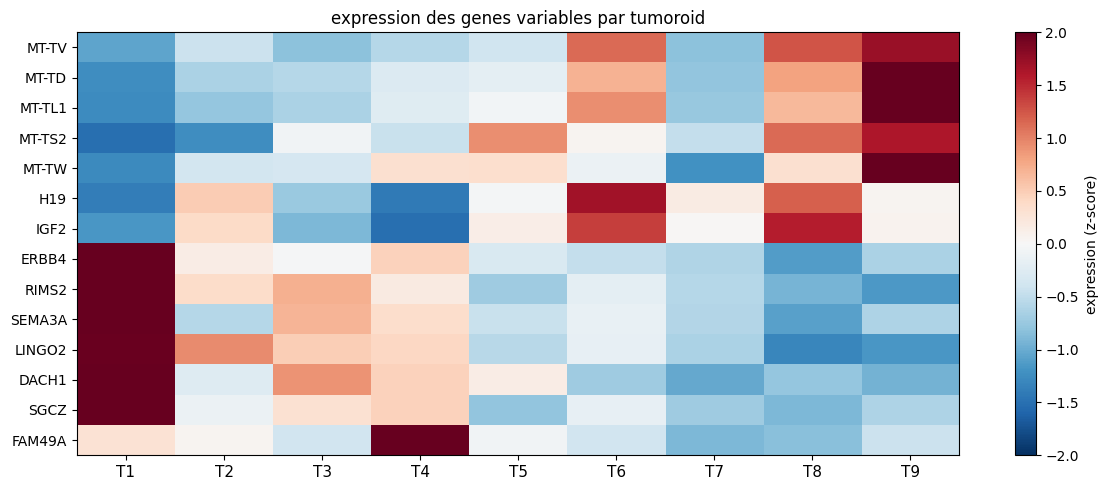

In [10]:
import matplotlib.pyplot as plt
import numpy as np

genes_cv = ['MT-TV', 'MT-TD', 'MT-TL1', 'MT-TS2', 'MT-TW',
            'H19', 'IGF2', 'ERBB4', 'RIMS2', 'SEMA3A',
            'LINGO2', 'DACH1', 'SGCZ', 'FAM49A']

idx_genes = [list(gene_names_filtered).index(g) for g in genes_cv if g in gene_names_filtered]
noms_trouves = [g for g in genes_cv if g in gene_names_filtered]

submatrix = mean_matrix[:, idx_genes]

# normaliser par gene pour mieux voir les differences (z-score)
submatrix_z = (submatrix - submatrix.mean(axis=0)) / (submatrix.std(axis=0) + 1e-6)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(submatrix_z.T, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)

ax.set_xticks(range(len(tumoroid_names)))
ax.set_xticklabels(tumoroid_names, fontsize=11)
ax.set_yticks(range(len(noms_trouves)))
ax.set_yticklabels(noms_trouves, fontsize=10)

plt.colorbar(im, ax=ax, label='expression (z-score)')
ax.set_title('expression des genes variables par tumoroid')
plt.tight_layout()
plt.savefig('heatmap_genes_variables.png', dpi=150)
plt.show()


**Interpretation :**  
Finalement  le premier axe de la PCA n'etait pas la position des tumoroides dans l'espace mais pluot leurs profils d'expression.  Les tumoroides a droite (T1, T4, T3, T2) expriment plus fortement les genes neuronaux comme ERBB4, DACH1 et RIMS2, tandis que les tumoroids a gauche (T9, T8) expriment plus fortement les genes mitochondriaux.

### 4b. Heatmap de correlation entre tumoroids

On calcule la correlation de Pearson entre chaque paire de tumoroids sur leurs profils moyens. Une correlation proche de 1 veut dire que les deux tumoroids expriment les memes genes dans les memes proportions.

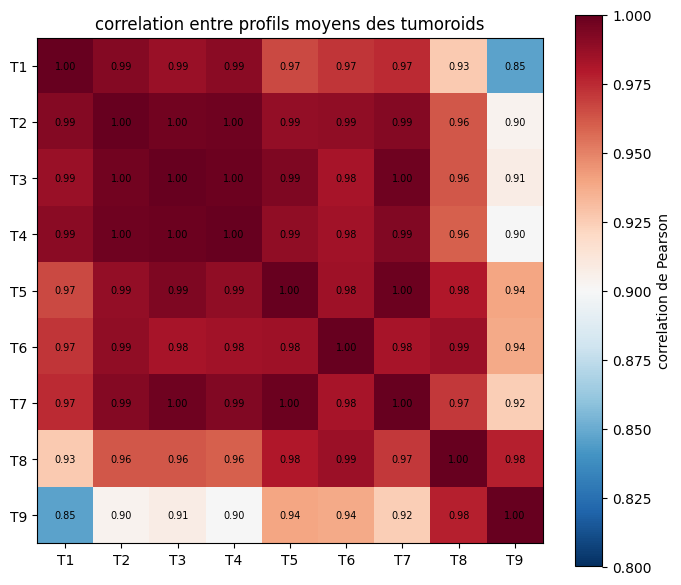

In [11]:
corr = np.corrcoef(mean_matrix)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=0.8, vmax=1)

ax.set_xticks(range(len(tumoroid_names)))
ax.set_xticklabels(tumoroid_names, fontsize=10)
ax.set_yticks(range(len(tumoroid_names)))
ax.set_yticklabels(tumoroid_names, fontsize=10)

# afficher les valeurs dans les cases
for i in range(len(tumoroid_names)):
    for j in range(len(tumoroid_names)):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, label='correlation de Pearson')
ax.set_title('correlation entre profils moyens des tumoroids')
plt.tight_layout()
plt.savefig('heatmap_correlation_tumoroids.png', dpi=150)
plt.show()

**Interpretation :**  
Toutes les correlations sont elevees (au dessus de 0.8), ce qui ce qui  est coherent avec les 51% de genes partages. Les differences restent visibles et coherentes avec le dendrogramme : les paires les plus similaires correspondent aux groupes qui fusionnent le plus tot dans le clustering.

### 4c. Nombre de genes exprimes par tumoroid

Une mesure simple : combien de genes distincts sont detectes dans chaque tumoroid ? Ca peut reflechir la complexite transcriptomique ou simplement le nombre de spots.

tumoroid    spots     genes exprimes   genes/spot (moyen)
------------------------------------------------------------
T1              5765            18820                70.3
T2             12888            22232                61.4
T3             10524            21318                72.1
T4              9159            21513                67.2
T5              7333            19015                65.1
T6             17896            22971                62.2
T7              5499            17267                55.8
T8              9284            19748                55.9
T9             10496            20929                61.7


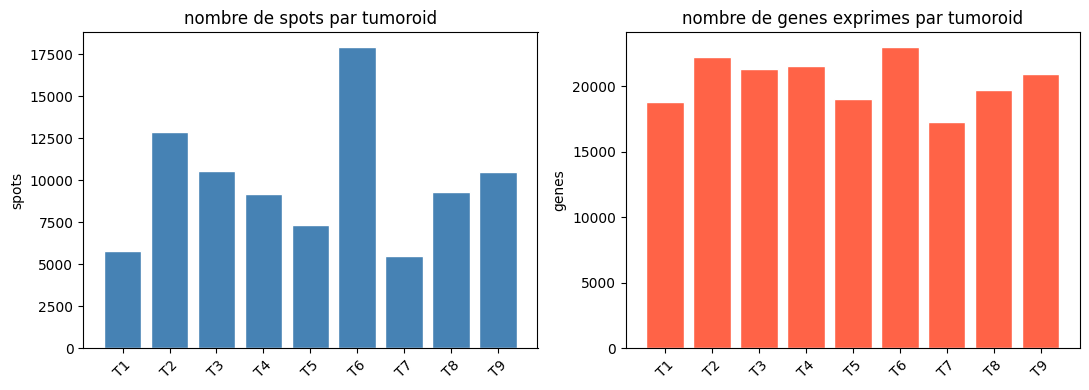

In [12]:
n_genes_par_tumoroid = {}
n_spots_par_tumoroid = {}

for name in tumoroid_names:
    adata_t = adata_tumoroids[name]
    expressed = np.asarray((adata_t.X > 0).sum(axis=0)).flatten() > 0
    n_genes_par_tumoroid[name] = expressed.sum()
    n_spots_par_tumoroid[name] = adata_t.n_obs

# tableau recapitulatif
print(f'{'tumoroid':10}  {'spots':8}  {'genes exprimes':15}  {'genes/spot (moyen)':18}')
print('-' * 60)
for name in tumoroid_names:
    n_spots = n_spots_par_tumoroid[name]
    n_genes = n_genes_par_tumoroid[name]
    mean_g_per_spot = adata_tumoroids[name].obs['n_genes'].mean() if 'n_genes' in adata_tumoroids[name].obs.columns else float('nan')
    print(f'{name:10}  {n_spots:8}  {n_genes:15}  {mean_g_per_spot:18.1f}')

# visualisation
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(tumoroid_names, [n_spots_par_tumoroid[t] for t in tumoroid_names], color='steelblue', edgecolor='white')
axes[0].set_title('nombre de spots par tumoroid')
axes[0].set_ylabel('spots')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(tumoroid_names, [n_genes_par_tumoroid[t] for t in tumoroid_names], color='tomato', edgecolor='white')
axes[1].set_title('nombre de genes exprimes par tumoroid')
axes[1].set_ylabel('genes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('stats_par_tumoroid.png', dpi=150)
plt.show()

**Interpretation :**  
T7 est le tumoroid le moins actif transcriptomiquement : il a le plus petit nombre de genes exprimes (17 267) et le plus faible nombre de genes par spot (55.8). Ca explique pourquoi il est isole dans le clustering et pourquoi le test VEGFA n'etait pas significatif pour lui  avec seulement 10 spots VEGFA+, le signal etait trop faible. A l'inverse, T6 a le plus de genes exprimes (22 971) et c'est aussi le tumoroid avec le signal VEGFA le plus fort (p = 8.17e-16).

## 5. Heatmap reorganisee par clustering hierarchique

On reorganise la heatmap des genes variables en regroupant a la fois les tumoroids et les genes par similarite.

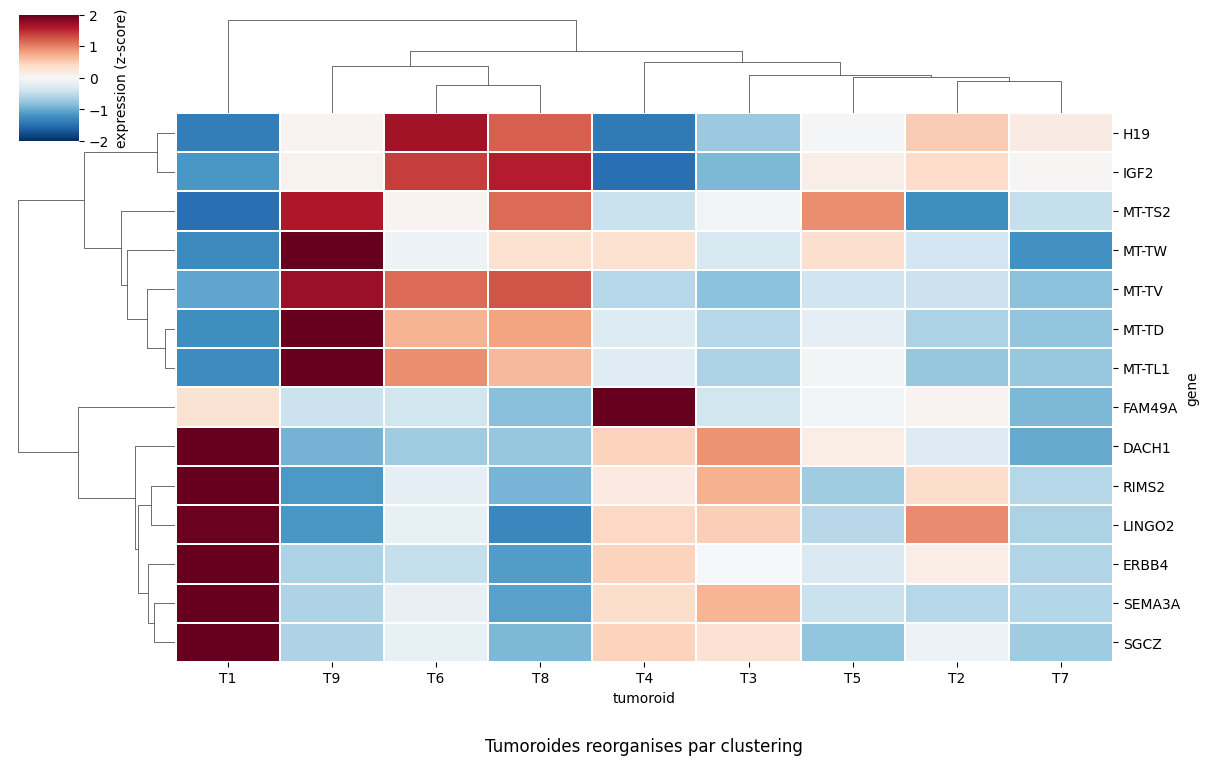

In [31]:
import seaborn as sns
import pandas as pd

# construire un dataframe avec genes en lignes et tumoroids en colonnes
df_heatmap = pd.DataFrame(submatrix_z.T, index=noms_trouves, columns=tumoroid_names)

# col_cluster=True reorganise les tumoroids, row_cluster=True reorganise les genes
g = sns.clustermap(
    df_heatmap,
    cmap='RdBu_r',
    vmin=-2, vmax=2,
    figsize=(12, 7),
    dendrogram_ratio=0.15,
    col_cluster=True,
    row_cluster=True,
    cbar_kws={'label': 'expression (z-score)'},
    linewidths=0.3,
    linecolor='white'
)
g.ax_heatmap.set_title('Tumoroides reorganises par clustering', pad=15,y=-0.2)
g.ax_heatmap.set_xlabel('tumoroid')
g.ax_heatmap.set_ylabel('gene')

plt.savefig('clustermap_genes_variables.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Centralite des 14 genes

Pour chaque gene, on teste si les spots qui l'expriment sont plus proches du centre du tumoroid que les spots qui ne l'expriment pas. On utilise le meme test Mann-Whitney que pour VEGFA, avec l'hypothese alternative='less' (les spots exprimes sont plus centraux). On applique une correction BH sur les p-valeurs pour tenir compte des tests multiples.

Hypothese : les genes mitochondriaux (MT-T) devraient etre plus centraux car le centre est plus hypoxique. Les genes de differenciation neuronale devraient etre plus peripheriques.

In [20]:
from scipy import stats

results_centralite = {}

for gene in noms_trouves:
    results_centralite[gene] = {}
    for name, adata_t in adata_tumoroids.items():
        if gene not in adata_t.var_names:
            results_centralite[gene][name] = {'n': 0, 'pval': float('nan')}
            continue

        coords_t  = adata_t.obsm['spatial']
        centre    = coords_t.mean(axis=0)
        distances = np.linalg.norm(coords_t - centre, axis=1)

        idx  = list(adata_t.var_names).index(gene)
        expr = np.asarray(adata_t.X[:, idx].todense()).flatten()
        expressed = expr > 0

        d_pos = distances[expressed]
        d_neg = distances[~expressed]

        if len(d_pos) < 3:
            results_centralite[gene][name] = {'n': int(expressed.sum()), 'pval': float('nan')}
            continue

        _, pval = stats.mannwhitneyu(d_pos, d_neg, alternative='less')
        results_centralite[gene][name] = {
            'n':       int(expressed.sum()),
            'pval':    float(pval),
            'med_pos': float(np.median(d_pos)),
            'med_neg': float(np.median(d_neg)),
        }

# tableau recapitulatif : pour chaque gene, dans combien de tumoroids est-il significativement central
print(f'{"gene":15}  {"sig/9":6}  {"p-valeurs par tumoroid"}')
print('-' * 80)
for gene in noms_trouves:
    pvals = [results_centralite[gene][t]['pval'] for t in tumoroid_names]
    n_sig = sum(1 for p in pvals if not np.isnan(p) and p < 0.05)
    pvals_str = '  '.join([f'{p:.2e}' if not np.isnan(p) else '  nan  ' for p in pvals])
    print(f'{gene:15}  {n_sig}/9    {pvals_str}')

gene             sig/9   p-valeurs par tumoroid
--------------------------------------------------------------------------------
MT-TV            9/9    9.45e-04  2.56e-186  7.91e-29  5.18e-05  5.42e-50  0.00e+00  4.13e-03  3.16e-258  7.83e-301
MT-TD            7/9    5.60e-02  1.16e-07  6.96e-06  5.40e-04  1.79e-03  1.39e-68  1.47e-01  3.18e-13  2.50e-11
MT-TL1           8/9    1.41e-05  1.03e-35  1.15e-29  3.98e-06  5.48e-17  9.47e-187  1.18e-01  3.33e-46  6.87e-74
MT-TS2           5/9    4.01e-01  3.90e-01  4.83e-10  4.98e-02  6.76e-04  9.59e-01  1.64e-03  2.24e-02  1.00e+00
MT-TW            3/9    1.03e-01  6.73e-02  1.21e-02  8.99e-01  3.79e-02  7.20e-01  7.87e-01  7.46e-04  9.03e-01
H19              7/9    1.32e-01  2.71e-06  4.65e-03  9.67e-01  1.03e-05  1.63e-26  3.44e-02  1.13e-10  4.26e-17
IGF2             5/9    8.06e-01  1.84e-01  1.88e-01  8.69e-01  1.38e-07  9.16e-17  1.72e-02  1.39e-08  1.19e-06
ERBB4            0/9    1.00e+00  9.09e-01  1.00e+00  9.42e-01  6.27e-01  9.

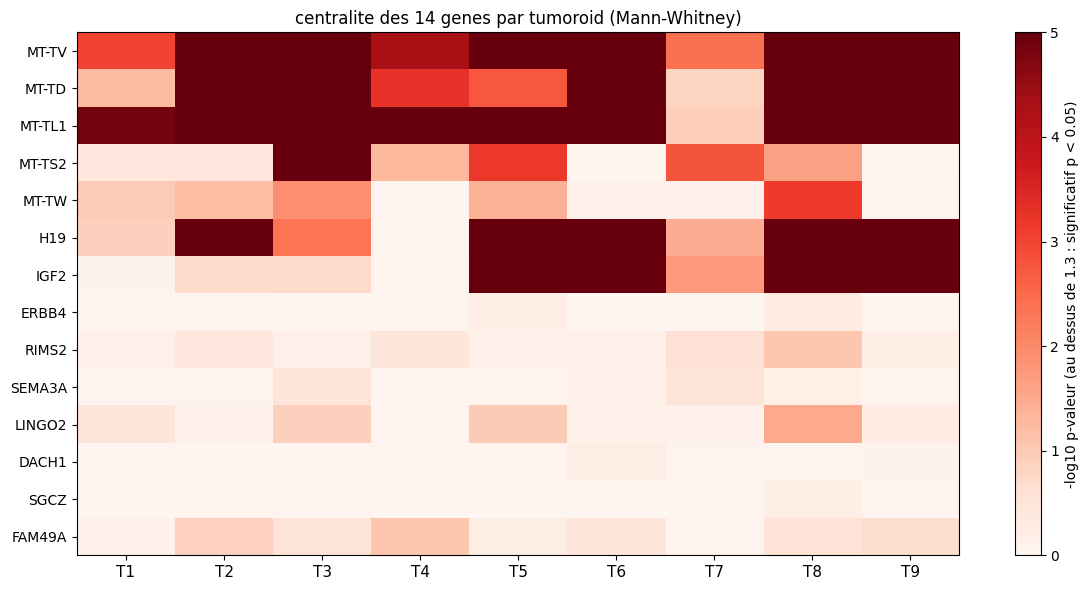

In [34]:
# heatmap des p-valeurs de centralite
# on affiche -log10(pval) : plus c'est rouge, plus le gene est central dans ce tumoroid

VMAX = 5

pval_matrix = np.zeros((len(noms_trouves), len(tumoroid_names)))

for i, gene in enumerate(noms_trouves):
    for j, name in enumerate(tumoroid_names):
        p = results_centralite[gene][name].get('pval', float('nan'))
        if np.isnan(p):
            pval_matrix[i, j] = 0
        elif p == 0:
            pval_matrix[i, j] = VMAX  # p=0 : valeur max, tres significatif
        else:
            pval_matrix[i, j] = min(-np.log10(p), VMAX)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pval_matrix, cmap='Reds', aspect='auto', vmin=0, vmax=VMAX)

ax.set_xticks(range(len(tumoroid_names)))
ax.set_xticklabels(tumoroid_names, fontsize=11)
ax.set_yticks(range(len(noms_trouves)))
ax.set_yticklabels(noms_trouves, fontsize=10)

plt.colorbar(im, ax=ax, label='-log10 p-valeur (au dessus de 1.3 : significatif p < 0.05)')
ax.set_title('centralite des 14 genes par tumoroid (Mann-Whitney)')
plt.tight_layout()
plt.savefig('centralite_14genes.png', dpi=150)
plt.show()

**Mon interpretation :**  
Les genes mitochondriaux (MT-TV, MT-TL1, MT-TD) sont significativement centraux dans la grande majorite des tumoroids. MT-TV est le plus robuste avec une centralite significative dans les 9 tumoroids. H19 et IGF2, les deux genes du locus de croissance, sont aussi centraux dans respectivement 7 et 5 tumoroids, ce qui suggere que la zone centrale des tumoroids est non seulement plus active mitochondrialement mais aussi plus active en termes de croissance.

A l'inverse, tous les genes de differenciation neuronale (ERBB4, RIMS2, SEMA3A, DACH1, SGCZ) ne sont significativement centraux dans aucun tumoroid.

T7 a moins de cases significatives que les autres, ce qui s'explique par son faible nombre de genes exprimes par spot (55.8), avec peu de spots exprimant chaque gene, le test manque de puissance statistique.

Ces resultats valident l'hypothese : les genes mitochondriaux et de croissance sont au centre, les genes neuronaux sont en peripherie.

## 8. Visualisation des signatures par type cellulaire

Les deux signatures biologiques identifiees par le clustering sont visualisees ici en relation avec les types cellulaires presents dans les tumoroides. La signature hypoxique regroupe les genes mitochondriaux et de croissance (MT-TV, MT-TD, MT-TL1, MT-TS2, MT-TW, BNIP3, DLK1, H19, IGF2). La signature neuronale regroupe les genes de differenciation (ERBB4, RIMS2, SEMA3A, LINGO2, DACH1, SGCZ, FAM49A, FGF14, EFNA5).

### Types cellulaires

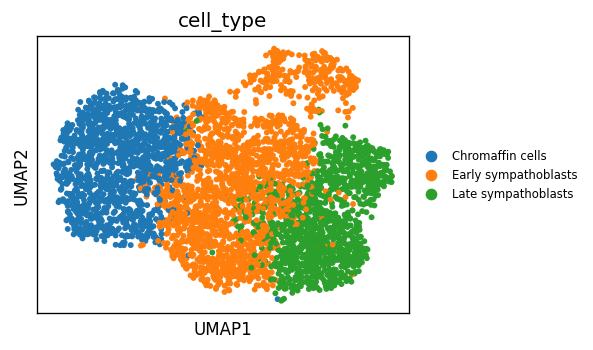

### Scores des signatures sur le UMAP

**Signature hypoxique / mitochondriale**

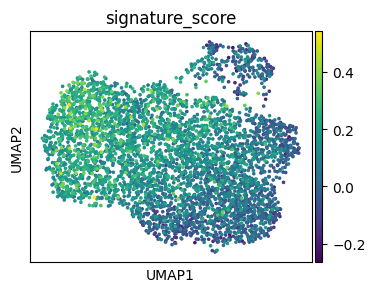

**Signature neuronale / differenciee**

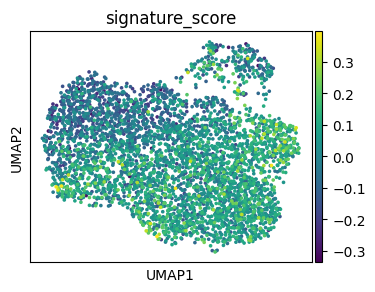



### Expression individuelle des genes de signature par type cellulaire

**Signature hypoxique**

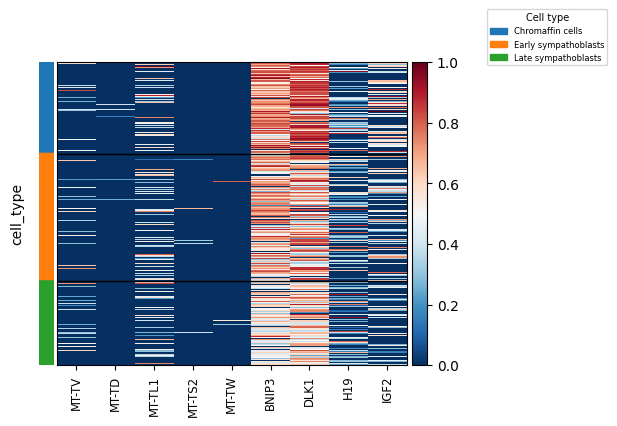

**Signature neuronale**

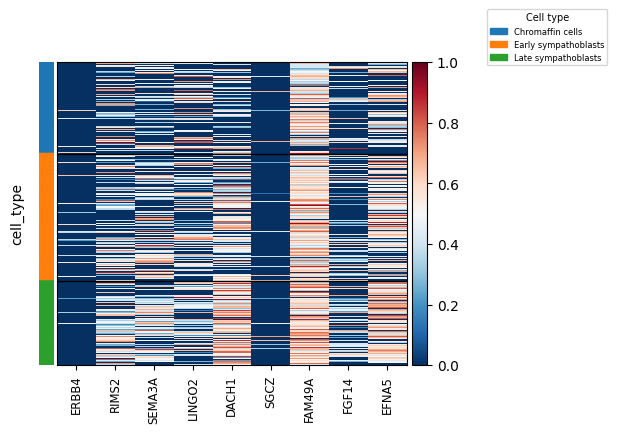



Les heatmaps montrent que l'expression individuelle de chaque gene de signature est heterogene et dispersee dans les trois types cellulaires sans distinction claire. Aucun gene ne separe à lui seul les types cellulaires. 

Les deux signatures genetiques identifiees par le clustering hierarchique correspondent a deux types cellulaires distincts. La signature mitochondriale est caracteristique des cellules chromaffines. La signature neuronale  est caracteristique des sympathoblastes tardifs.